## Señal senoidal de 1 W de potencia

Parto de la función `mi_funcion_sen` desarrollada en la evidencia anterior, que genera:

$$x(t) = DC + V_{max} \cdot \sin(2\pi f t + \phi)$$

El objetivo es que la señal generada tenga **potencia media unitaria** ($P_x = 1$ W), que es la normalización habitual para después poder fijar el SNR directamente a partir de la potencia del ruido.

### Paso 1

Importación de las librerías a utilizar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Paso 2

Defino la función *mi_funcion_sen()*, la misma que utilicé en la evidencia anterior.

In [2]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

### Paso 3: ¿qué amplitud corresponde a 1 W?

La potencia media de una señal discreta de N muestras es:

$$P_x = \frac{1}{N}\sum_{k=0}^{N-1} |x[k]|^2$$

Para una senoidal de media nula ($DC = 0$) y amplitud $V_{max}$, esa suma da el valor conocido:

$$P_x = \frac{V_{max}^2}{2}$$

Entonces, si quiero $P_x = 1$ W, despejo la amplitud:

$$\frac{V_{max}^2}{2} = 1 \quad \Rightarrow \quad V_{max} = \sqrt{2} \approx 1.4142\ V$$

Es decir, la senoidal de potencia unitaria es la que tiene **valor eficaz (RMS) igual a 1 V**, ya que $P = V_{RMS}^2$ y $V_{RMS} = V_{max}/\sqrt{2}$.

Importante: la condición de 1 W depende **únicamente de la amplitud**. No depende de la frecuencia, de la fase ni de la cantidad de muestras (siempre que se muestree una cantidad entera de ciclos o N sea suficientemente grande). En cambio, sí se rompe si agrego componente de continua, porque en ese caso $P_x = DC^2 + V_{max}^2/2$.

In [3]:
N  = 1000
fs = 1000

vmax_1w = np.sqrt(2)  # amplitud que garantiza potencia media de 1 W

tt, xx = mi_funcion_sen(vmax=vmax_1w, dc=0, ff=5, ph=0, nn=N, fs=fs)

print(f'Amplitud utilizada  Vmax = {vmax_1w:.4f} V')
print(f'Valor eficaz        Vrms = {vmax_1w / np.sqrt(2):.4f} V')

Amplitud utilizada  Vmax = 1.4142 V
Valor eficaz        Vrms = 1.0000 V


### Paso 4: verificación de la potencia

Calculo la potencia media directamente sobre las muestras generadas y la comparo con el valor teórico.

In [4]:
def potencia_media(xx):
    return np.mean(xx ** 2)


Px = potencia_media(xx)

print(f'Potencia media medida   Px = {Px:.6f} W')
print(f'Potencia media teorica       = {vmax_1w ** 2 / 2:.6f} W')
print(f'Varianza de la señal         = {np.var(xx):.6f}')
print(f'Valor medio (DC)             = {np.mean(xx):.2e} V')

Potencia media medida   Px = 1.000000 W
Potencia media teorica       = 1.000000 W
Varianza de la señal         = 1.000000
Valor medio (DC)             = -8.53e-17 V


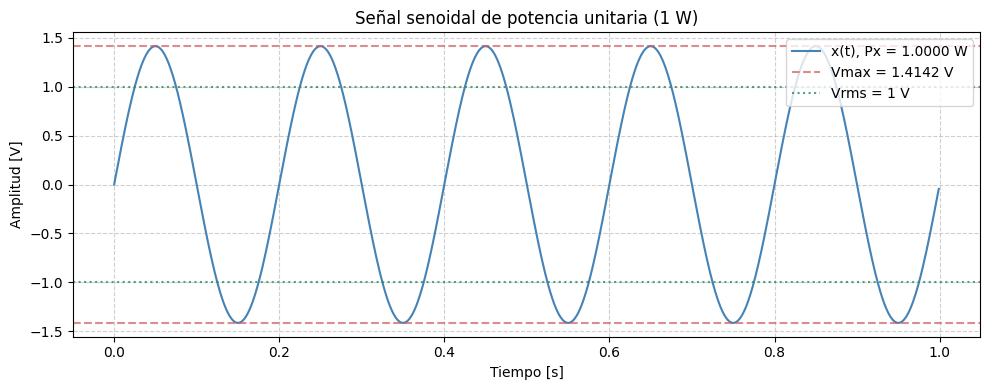

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue', label=f'x(t), Px = {Px:.4f} W')
plt.axhline( vmax_1w, color='indianred', linestyle='--', alpha=0.7, label=f'Vmax = {vmax_1w:.4f} V')
plt.axhline(-vmax_1w, color='indianred', linestyle='--', alpha=0.7)
plt.axhline( 1, color='seagreen', linestyle=':', alpha=0.8, label='Vrms = 1 V')
plt.axhline(-1, color='seagreen', linestyle=':', alpha=0.8)
plt.title('Señal senoidal de potencia unitaria (1 W)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Normalización genérica

El despeje anterior sirve porque conozco la expresión analítica de la senoidal. Una forma más general de llevar **cualquier** señal a 1 W es dividirla por la raíz de su propia potencia:

$$x_{norm}[k] = \frac{x[k]}{\sqrt{P_x}}$$

Esto es útil, por ejemplo, para normalizar la señal cuadrada o el pulso gaussiano de la evidencia anterior, donde la relación entre amplitud y potencia no es $V_{max}^2/2$.

In [6]:
def normalizar_potencia(xx, potencia=1):
    """Escala xx para que su potencia media sea la indicada (por defecto 1 W)."""
    return xx * np.sqrt(potencia / potencia_media(xx))


# Arranco de una senoidal de amplitud arbitraria y la normalizo
tt, xx_arbitraria = mi_funcion_sen(vmax=7, dc=0, ff=5, ph=np.pi/4, nn=N, fs=fs)
xx_norm = normalizar_potencia(xx_arbitraria, potencia=1)

print(f'Potencia antes de normalizar   = {potencia_media(xx_arbitraria):.4f} W')
print(f'Potencia despues de normalizar = {potencia_media(xx_norm):.6f} W')
print(f'Amplitud resultante            = {np.max(xx_norm):.4f} V  (~ sqrt(2) = {np.sqrt(2):.4f})')

Potencia antes de normalizar   = 24.5000 W
Potencia despues de normalizar = 1.000000 W
Amplitud resultante            = 1.4142 V  (~ sqrt(2) = 1.4142)


### Análisis de resultados

- Para obtener una senoidal de 1 W de potencia media hay que usar $V_{max} = \sqrt{2} \approx 1.4142$ V, o equivalentemente un valor eficaz de 1 V.

- La potencia medida sobre las muestras coincide con la teórica. La diferencia es despreciable porque en este caso se muestrea una cantidad entera de ciclos (5 Hz con N = 1000 y fs = 1000 Hz da exactamente 5 ciclos); si el número de ciclos no fuera entero aparecería un pequeño error de estimación.

- Como la señal tiene valor medio nulo, su potencia coincide con su varianza. Por eso normalizar a 1 W equivale a dejarla con desvío estándar unitario.

- La normalización genérica `x / sqrt(Px)` llega al mismo resultado sin necesidad de conocer la fórmula analítica de la señal, y es la que conviene usar cuando se quiere fijar el SNR: con la señal en 1 W, la potencia del ruido queda directamente determinada por el SNR deseado ($P_n = 10^{-SNR_{dB}/10}$).

## Ruido parametrizado por SNR

Hasta acá el ruido se controlaba con el desvío estándar $\sigma$, que es un parámetro **de la distribución** y no una magnitud que describa cuánto se degrada la señal. Lo que interesa en la práctica es la relación señal-ruido:

$$SNR_{dB} = 10\log_{10}\left(\frac{P_x}{P_n}\right)$$

Así que doy vuelta la cuenta: en lugar de elegir $\sigma$ y medir qué SNR quedó, **fijo el SNR** y despejo la potencia de ruido necesaria:

$$P_n = \frac{P_x}{10^{SNR_{dB}/10}}$$

Y como el ruido es gaussiano de media nula, su potencia es directamente su varianza, con lo cual el desvío que le tengo que pasar a `np.random.normal` es:

$$\sigma = \sqrt{P_n} = \sqrt{\frac{P_x}{10^{SNR_{dB}/10}}}$$

De esta forma $\sigma$ deja de ser un parámetro de entrada y pasa a ser una variable interna de la función. El caso particular de la señal normalizada a 1 W es el que ya venía usando: con $P_x = 1$ queda $P_n = 10^{-SNR_{dB}/10}$ y $\sigma = 10^{-SNR_{dB}/20}$.

In [7]:
def mi_funcion_ruido(snr_db=10, pot_senal=1, mu=0, nn=1000, fs=1000):
    """Ruido blanco gaussiano generado a partir del SNR deseado.

    En lugar de recibir sigma, recibe el SNR en dB y la potencia de la
    señal util. El desvio estandar sale de despejar Pn = Px / 10^(SNR/10)
    y usar que, para media nula, Pn = sigma^2.
    """
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    pot_ruido = pot_senal / (10 ** (snr_db / 10))
    sigma = np.sqrt(pot_ruido)
    nn_ruido = np.random.normal(mu, sigma, (nn, 1))
    return tt, nn_ruido


def calcular_snr(xx, nn_ruido):
    """SNR en dB medido sobre las muestras, usando la varianza como potencia."""
    return 10 * np.log10(np.var(xx) / np.var(nn_ruido))

### Verificación de la potencia del ruido con la varianza

Genero la señal contaminada $x'(t) = x(t) + n(t)$ pidiendo un SNR de 6 dB y controlo con `np.var()` que la potencia del ruido sea la esperada.

Como señal y ruido son incorrelados y ambos de media nula, las potencias se suman: $P_{x'} = P_x + P_n$.

In [8]:
np.random.seed(0)  # semilla fija para que el experimento sea reproducible

# Señal util: senoidal de 1 W, sin componente de continua
tt, xx = mi_funcion_sen(vmax=vmax_1w, dc=0, ff=5, ph=0, nn=N, fs=fs)
Px = potencia_media(xx)

snr_pedido = 6  # dB

_, nn_ruido = mi_funcion_ruido(snr_db=snr_pedido, pot_senal=Px, mu=0, nn=N, fs=fs)
xx_ruidosa = xx + nn_ruido

# Potencia del ruido: como la media es nula, potencia == varianza
Pn_teo = Px / (10 ** (snr_pedido / 10))
Pn     = np.var(nn_ruido)
Pxr    = np.var(xx_ruidosa)

print(f'SNR pedido                            = {snr_pedido} dB')
print(f'sigma que uso la funcion              = {np.sqrt(Pn_teo):.4f} V')
print()
print(f'Potencia señal   Px = np.var(xx)      = {Px:.4f} W')
print(f'Potencia ruido   Pn = np.var(n)       = {Pn:.4f} W   (teorica: {Pn_teo:.4f} W)')
print(f'Valor medio del ruido  np.mean(n)     = {np.mean(nn_ruido):+.4f} V   (debe ser ~0)')
print(f"Potencia de x'   = np.var(xx_ruidosa) = {Pxr:.4f} W   (~ Px + Pn = {Px + Pn:.4f} W)")
print()
print(f'SNR medido = {calcular_snr(xx, nn_ruido):.2f} dB')

SNR pedido                            = 6 dB
sigma que uso la funcion              = 0.5012 V

Potencia señal   Px = np.var(xx)      = 1.0000 W
Potencia ruido   Pn = np.var(n)       = 0.2447 W   (teorica: 0.2512 W)
Valor medio del ruido  np.mean(n)     = -0.0227 V   (debe ser ~0)
Potencia de x'   = np.var(xx_ruidosa) = 1.2200 W   (~ Px + Pn = 1.2447 W)

SNR medido = 6.11 dB


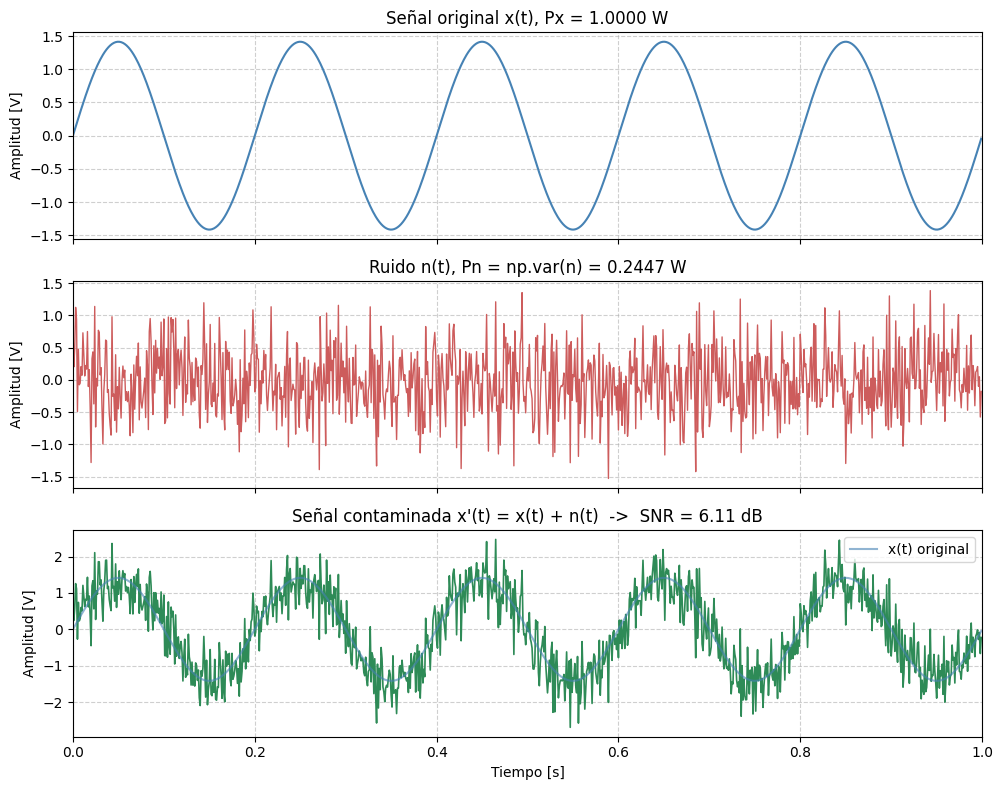

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(tt, xx, linewidth=1.5, color='steelblue')
axs[0].set_title(f'Señal original x(t), Px = {Px:.4f} W')
axs[0].set_ylabel('Amplitud [V]')

axs[1].plot(tt, nn_ruido, linewidth=1.0, color='indianred')
axs[1].set_title(f'Ruido n(t), Pn = np.var(n) = {Pn:.4f} W')
axs[1].set_ylabel('Amplitud [V]')

axs[2].plot(tt, xx_ruidosa, linewidth=1.2, color='seagreen')
axs[2].plot(tt, xx, linewidth=1.5, color='steelblue', alpha=0.6, label='x(t) original')
axs[2].set_title(f"Señal contaminada x'(t) = x(t) + n(t)  ->  SNR = {calcular_snr(xx, nn_ruido):.2f} dB")
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Amplitud [V]')
axs[2].legend(loc='upper right')

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

### Barrido de SNR

Repito el experimento pidiendo distintos SNR y en cada caso comparo la potencia de ruido **teórica** (la que despejó la función) contra la **medida** con `np.var()`.

 SNR pedido |   sigma | Pn teorica |  Pn medida | SNR medido
------------------------------------------------------------
      20 dB |  0.1000 |     0.0100 |     0.0097 |   20.11 dB
      10 dB |  0.3162 |     0.1000 |     0.0937 |   10.28 dB
       3 dB |  0.7079 |     0.5012 |     0.4563 |    3.41 dB
      -6 dB |  1.9953 |     3.9811 |     4.1080 |   -6.14 dB


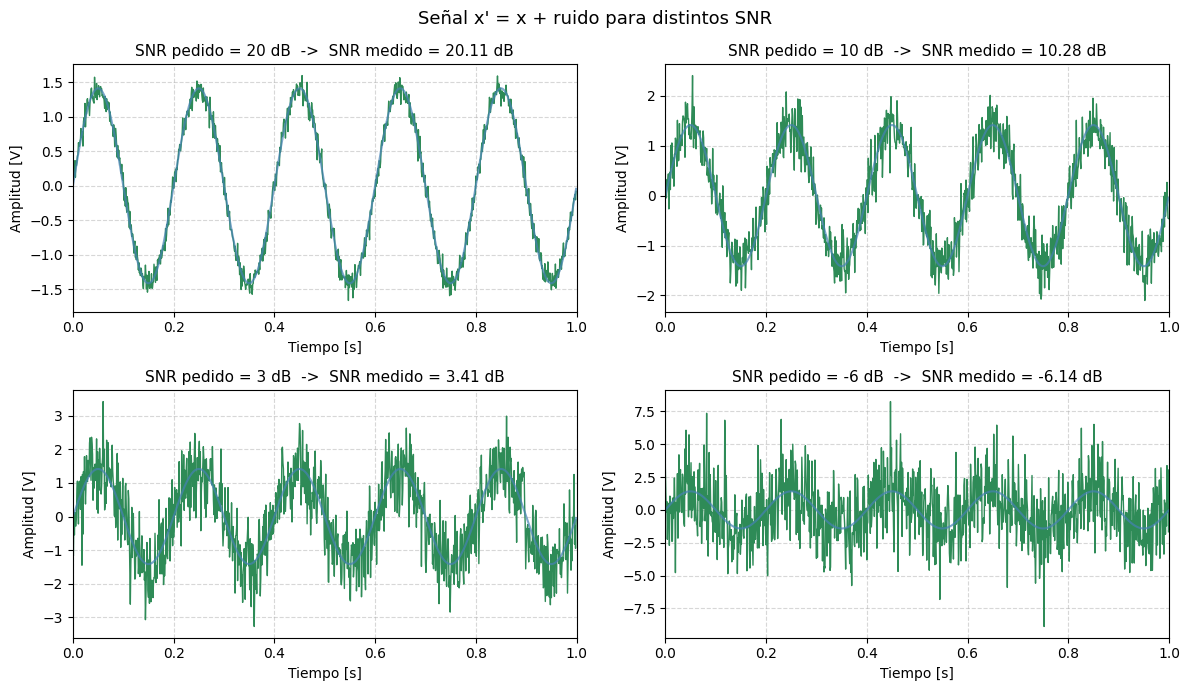

In [10]:
np.random.seed(0)

snrs = [20, 10, 3, -6]  # dB

print(f'{"SNR pedido":>11} | {"sigma":>7} | {"Pn teorica":>10} | {"Pn medida":>10} | {"SNR medido":>10}')
print('-' * 60)

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Señal x' = x + ruido para distintos SNR", fontsize=13)

for ax, snr_i in zip(axs.flat, snrs):
    _, nn_i = mi_funcion_ruido(snr_db=snr_i, pot_senal=Px, mu=0, nn=N, fs=fs)
    xx_i = xx + nn_i

    Pn_teo_i = Px / (10 ** (snr_i / 10))
    Pn_i     = np.var(nn_i)
    snr_med  = calcular_snr(xx, nn_i)

    print(f'{snr_i:>8} dB | {np.sqrt(Pn_teo_i):>7.4f} | {Pn_teo_i:>10.4f} | {Pn_i:>10.4f} | {snr_med:>7.2f} dB')

    ax.plot(tt, xx_i, linewidth=1.0, color='seagreen')
    ax.plot(tt, xx, linewidth=1.5, color='steelblue', alpha=0.7)
    ax.set_title(f'SNR pedido = {snr_i} dB  ->  SNR medido = {snr_med:.2f} dB', fontsize=11)
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Amplitud [V]')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

### Análisis de resultados

- Parametrizar por SNR desacopla el experimento de la amplitud de la señal: la función calcula internamente $\sigma = \sqrt{P_x / 10^{SNR_{dB}/10}}$, así que sirve igual para la senoidal de 1 W, para la cuadrada o para el pulso gaussiano, sin tener que recalcular a mano qué $\sigma$ corresponde en cada caso.

- La potencia del ruido se verifica con `np.var()` y no con `np.mean(n**2)` porque son equivalentes: al ser de media nula, $P_n = \sigma_n^2 + \mu_n^2 = \sigma_n^2$. La media medida da del orden de $10^{-2}$ V en vez de exactamente 0, lo cual es esperable para una estimación con N finito.

- La potencia medida no coincide exactamente con la teórica y el SNR medido queda a algunas décimas de dB del pedido. Esto **no es un error de la parametrización**: $\sigma$ es el desvío de la *distribución*, mientras que `np.var()` es el desvío de la *realización* particular de N muestras. El error relativo de esa estimación cae como $\sqrt{2/N}$, así que aumentando N el SNR medido converge al pedido.

- Si hiciera falta que el SNR medido sea exacto, alcanza con normalizar la realización del ruido a la potencia deseada (`n * np.sqrt(Pn_teo / np.var(n))`, la misma idea que `normalizar_potencia`). El costo es que el ruido deja de ser una muestra "honesta" de la distribución, porque se le fuerza la varianza.

- En el barrido se ve que la potencia del ruido crece un factor 10 cada 10 dB que baja el SNR. Con 20 dB la senoidal se distingue perfectamente, con 3 dB apenas se intuye, y con -6 dB el ruido tiene 4 veces la potencia de la señal y la senoidal queda enmascarada en el dominio temporal (aunque seguiría siendo recuperable en frecuencia, porque el ruido blanco reparte su potencia en todo el espectro y la senoidal la concentra en una única frecuencia).